In [1]:
import pandas as pd
from utils.ml_utils_v2 import EnsembleProjections
import os
import joblib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
ep = EnsembleProjections()

In [4]:
# Set up paths
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
ENSEMBLE_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "ensemble")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")

In [5]:
# Ensemble params
n_scenarios = 10

# Load data
training_df_log_transformed = pd.read_csv(os.path.join(TRAINING_DIR_PATH, "training_df_log_transformed.csv"))
training_df_lags = pd.read_csv(os.path.join(TRAINING_DIR_PATH, "training_df_lags.csv"))
ensemble_arima_df = pd.read_csv(os.path.join(ENSEMBLE_DIR_PATH, f"ensemble_arima_{n_scenarios}_df.csv"))

In [6]:
# Print shapes
print(f"Training df log transformed shape: {training_df_log_transformed.shape}")
print(f"Training df lags shape: {training_df_lags.shape}")
print(f"Ensemble ARIMA df shape: {ensemble_arima_df.shape}") 

Training df log transformed shape: (3652, 19)
Training df lags shape: (3652, 19)
Ensemble ARIMA df shape: (14940, 17)


In [7]:
# Get the models from the models directory with keys without .pkl extension
models = {}
for model_name in os.listdir(MODELS_DIR_PATH):
    if model_name.endswith(".pkl"):
        model_path = os.path.join(MODELS_DIR_PATH, model_name)
        key_name = model_name[:-4]  # remove .pkl extension
        models[key_name] = joblib.load(model_path)

models.keys()

dict_keys(['reg_with_isos_enet_pipeline', 'reg_with_isos_xgb_pipeline', 'reg_no_isos_xgb_pipeline', 'reg_no_isos_enet_pipeline'])

In [8]:
# Get a df with only iso_alpha_3, income_group and region cols
iso_alpha_3_cols = ["iso_alpha_3", "income_group", "region"]
income_group_region_mapping_df = training_df_log_transformed[iso_alpha_3_cols].drop_duplicates().reset_index(drop=True)
income_group_region_mapping_df.head()

,iso_alpha_3,income_group,region
0,ABW,High income,Latin America & Caribbean
1,AFG,Low income,South Asia
2,AGO,Lower middle income,Africa Eastern and Southern
3,ALB,Upper middle income,Europe & Central Asia
4,ARE,High income,Middle East & North Africa


In [9]:
initial_conditions_df = training_df_lags[training_df_lags["year"] == 2022].copy()
initial_conditions_df = initial_conditions_df.reset_index(drop=True)
initial_conditions_df = initial_conditions_df[["iso_alpha_3", "year", "total_emissions"]]
initial_conditions_df

,iso_alpha_3,year,total_emissions
0,ABW,2022,0.496683
1,AFG,2022,38.457458
2,AGO,2022,136.889648
3,ALB,2022,9.252882
4,ARE,2022,286.675891
...,...,...,...
161,VNM,2022,449.692567
162,YEM,2022,36.119043
163,ZAF,2022,503.193706
164,ZMB,2022,77.421588


In [10]:
ensemble_arima_df.head()

,iso_alpha_3,future_id,year,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,gdp_per_capita_growth_pct,manufacturing_pct_of_gdp,log_pop_total,log_gdp_2021_ppp_intl_usd,log_gdp_per_capita_2021_ppp_intl_usd,log_imports_pct_of_gdp,log_industry_pct_of_gdp,log_exports_pct_of_gdp,log_gdp_2021_ppp_intl_usd_lag1,log_pop_total_lag1
0,ABW,id_ABW_1,2022,-0.180030,11.205487,2.333332,5.484701,5.341339,2.910329,11.580216,21.944451,10.448744,4.453318,2.732430,4.357860,22.059441,11.588088
1,ABW,id_ABW_2,2022,0.332700,7.522974,2.333333,-2.154597,9.861790,2.764734,11.585601,22.099318,10.388836,4.422975,2.497382,4.415467,22.091542,11.571629
2,ABW,id_ABW_3,2022,0.015151,8.381474,2.333333,8.847171,-0.156311,4.929563,11.583964,22.122837,10.610833,4.359771,2.635693,4.460352,22.089157,11.584468
3,ABW,id_ABW_4,2022,-0.541679,6.757798,2.333333,-6.826270,1.846420,4.669740,11.580504,22.088161,10.541005,4.502801,2.781526,4.312810,22.116946,11.580032
4,ABW,id_ABW_5,2022,-0.041952,9.479588,2.333335,2.737891,-7.167315,4.159345,11.583095,22.019037,10.617960,4.432754,2.732050,4.167588,22.099721,11.585075


In [11]:
# Merge the income group and region mapping df with the ensemble df
ensemble_arima_df = pd.merge(ensemble_arima_df, income_group_region_mapping_df,
                             on="iso_alpha_3", how="left")

ensemble_arima_df.head()

,iso_alpha_3,future_id,year,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,gdp_per_capita_growth_pct,manufacturing_pct_of_gdp,log_pop_total,log_gdp_2021_ppp_intl_usd,log_gdp_per_capita_2021_ppp_intl_usd,log_imports_pct_of_gdp,log_industry_pct_of_gdp,log_exports_pct_of_gdp,log_gdp_2021_ppp_intl_usd_lag1,log_pop_total_lag1,income_group,region
0,ABW,id_ABW_1,2022,-0.180030,11.205487,2.333332,5.484701,5.341339,2.910329,11.580216,21.944451,10.448744,4.453318,2.732430,4.357860,22.059441,11.588088,High income,Latin America & Caribbean
1,ABW,id_ABW_2,2022,0.332700,7.522974,2.333333,-2.154597,9.861790,2.764734,11.585601,22.099318,10.388836,4.422975,2.497382,4.415467,22.091542,11.571629,High income,Latin America & Caribbean
2,ABW,id_ABW_3,2022,0.015151,8.381474,2.333333,8.847171,-0.156311,4.929563,11.583964,22.122837,10.610833,4.359771,2.635693,4.460352,22.089157,11.584468,High income,Latin America & Caribbean
3,ABW,id_ABW_4,2022,-0.541679,6.757798,2.333333,-6.826270,1.846420,4.669740,11.580504,22.088161,10.541005,4.502801,2.781526,4.312810,22.116946,11.580032,High income,Latin America & Caribbean
4,ABW,id_ABW_5,2022,-0.041952,9.479588,2.333335,2.737891,-7.167315,4.159345,11.583095,22.019037,10.617960,4.432754,2.732050,4.167588,22.099721,11.585075,High income,Latin America & Caribbean


## Let's check the feature variables projections

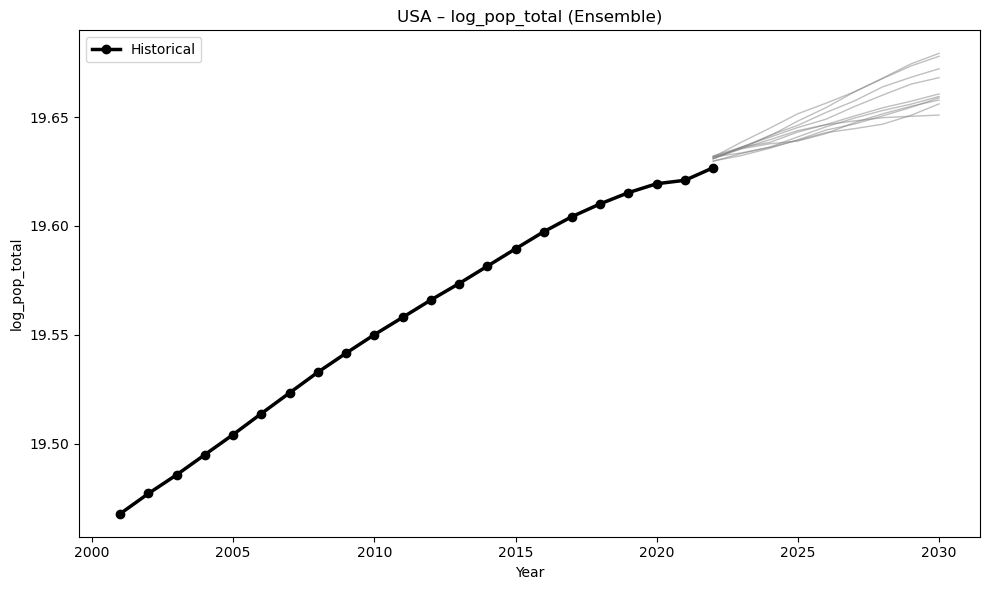

In [12]:
ep.plot_ensemble_time_series(
    df=ensemble_arima_df, 
    iso_alpha_3="USA",
    column="log_pop_total",
    hist_df=training_df_log_transformed)

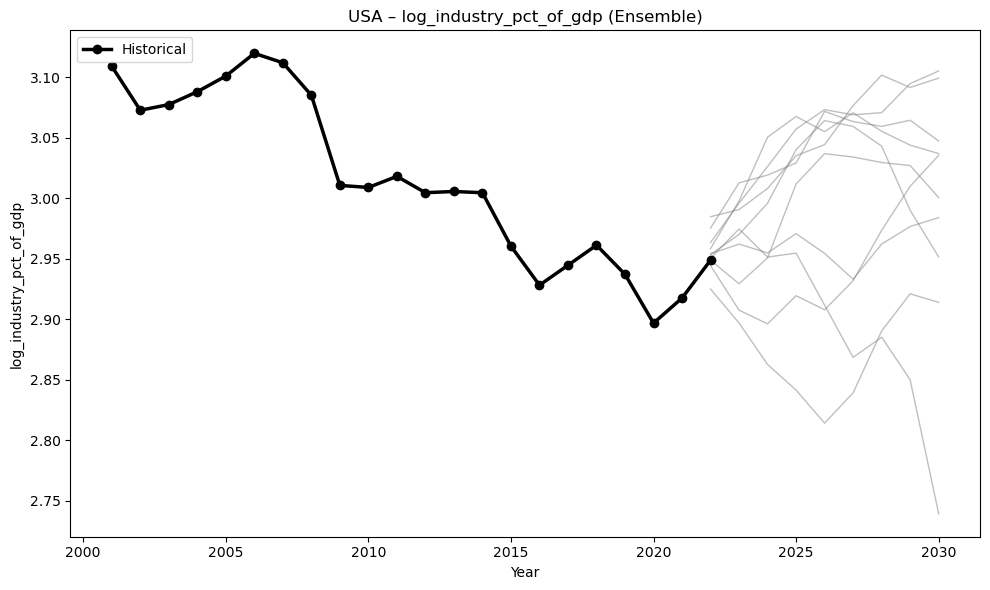

In [13]:
ep.plot_ensemble_time_series(
    df=ensemble_arima_df, 
    iso_alpha_3="USA",
    column="log_industry_pct_of_gdp",
    hist_df=training_df_log_transformed)

## Let's do a prediction and see how it looks without rescaling

In [14]:
# Get feature cols
feature_cols_no_isos = [c for c in  training_df_log_transformed.columns if c not in ["iso_alpha_3", "log_total_emissions"]]
feature_cols_no_isos

['income_group',
 'region',
 'year',
 'pop_growth',
 'renewable_energy_consumption_pct',
 'forest_area_pct',
 'gdp_growth_pct',
 'gdp_per_capita_growth_pct',
 'manufacturing_pct_of_gdp',
 'log_pop_total',
 'log_gdp_2021_ppp_intl_usd',
 'log_gdp_per_capita_2021_ppp_intl_usd',
 'log_imports_pct_of_gdp',
 'log_industry_pct_of_gdp',
 'log_exports_pct_of_gdp',
 'log_gdp_2021_ppp_intl_usd_lag1',
 'log_pop_total_lag1']

In [15]:
feature_cols_with_isos = [c for c in training_df_log_transformed.columns if c not in ["log_total_emissions"]]
feature_cols_with_isos

['iso_alpha_3',
 'income_group',
 'region',
 'year',
 'pop_growth',
 'renewable_energy_consumption_pct',
 'forest_area_pct',
 'gdp_growth_pct',
 'gdp_per_capita_growth_pct',
 'manufacturing_pct_of_gdp',
 'log_pop_total',
 'log_gdp_2021_ppp_intl_usd',
 'log_gdp_per_capita_2021_ppp_intl_usd',
 'log_imports_pct_of_gdp',
 'log_industry_pct_of_gdp',
 'log_exports_pct_of_gdp',
 'log_gdp_2021_ppp_intl_usd_lag1',
 'log_pop_total_lag1']

In [16]:
xgb_no_isos_df = ep.predict_ensemble_emissions(ensemble_arima_df, models["reg_no_isos_xgb_pipeline"], feature_cols=feature_cols_no_isos)
xgb_no_isos_df.head()

,iso_alpha_3,future_id,year,pop_growth,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,gdp_per_capita_growth_pct,manufacturing_pct_of_gdp,log_pop_total,...,log_gdp_per_capita_2021_ppp_intl_usd,log_imports_pct_of_gdp,log_industry_pct_of_gdp,log_exports_pct_of_gdp,log_gdp_2021_ppp_intl_usd_lag1,log_pop_total_lag1,income_group,region,log_total_emissions,total_emissions
0,ABW,id_ABW_1,2022,-0.180030,11.205487,2.333332,5.484701,5.341339,2.910329,11.580216,...,10.448744,4.453318,2.732430,4.357860,22.059441,11.588088,High income,Latin America & Caribbean,0.271671,1.312155
1,ABW,id_ABW_2,2022,0.332700,7.522974,2.333333,-2.154597,9.861790,2.764734,11.585601,...,10.388836,4.422975,2.497382,4.415467,22.091542,11.571629,High income,Latin America & Caribbean,0.246503,1.279543
2,ABW,id_ABW_3,2022,0.015151,8.381474,2.333333,8.847171,-0.156311,4.929563,11.583964,...,10.610833,4.359771,2.635693,4.460352,22.089157,11.584468,High income,Latin America & Caribbean,0.287102,1.332560
3,ABW,id_ABW_4,2022,-0.541679,6.757798,2.333333,-6.826270,1.846420,4.669740,11.580504,...,10.541005,4.502801,2.781526,4.312810,22.116946,11.580032,High income,Latin America & Caribbean,0.336492,1.400027
4,ABW,id_ABW_5,2022,-0.041952,9.479588,2.333335,2.737891,-7.167315,4.159345,11.583095,...,10.617960,4.432754,2.732050,4.167588,22.099721,11.585075,High income,Latin America & Caribbean,0.317021,1.373031


In [17]:
enet_no_isos_df = ep.predict_ensemble_emissions(ensemble_arima_df, models["reg_no_isos_enet_pipeline"], feature_cols=feature_cols_no_isos)
xgb_with_isos_df = ep.predict_ensemble_emissions(ensemble_arima_df, models["reg_with_isos_xgb_pipeline"], feature_cols=feature_cols_with_isos)
enet_with_isos_df = ep.predict_ensemble_emissions(ensemble_arima_df, models["reg_with_isos_enet_pipeline"], feature_cols=feature_cols_with_isos)

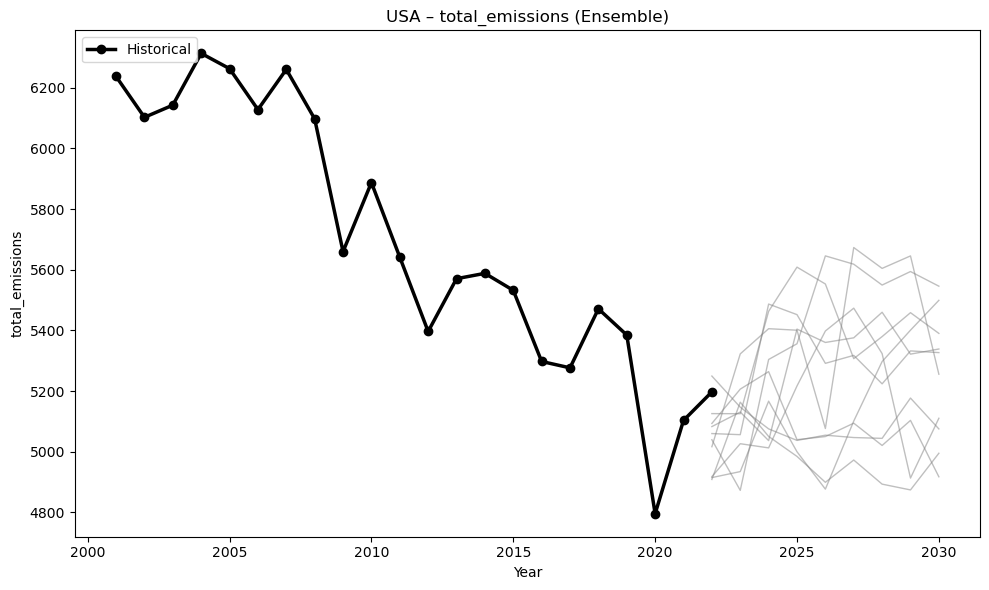

In [18]:
ep.plot_ensemble_time_series(
    df=xgb_no_isos_df, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df_lags)

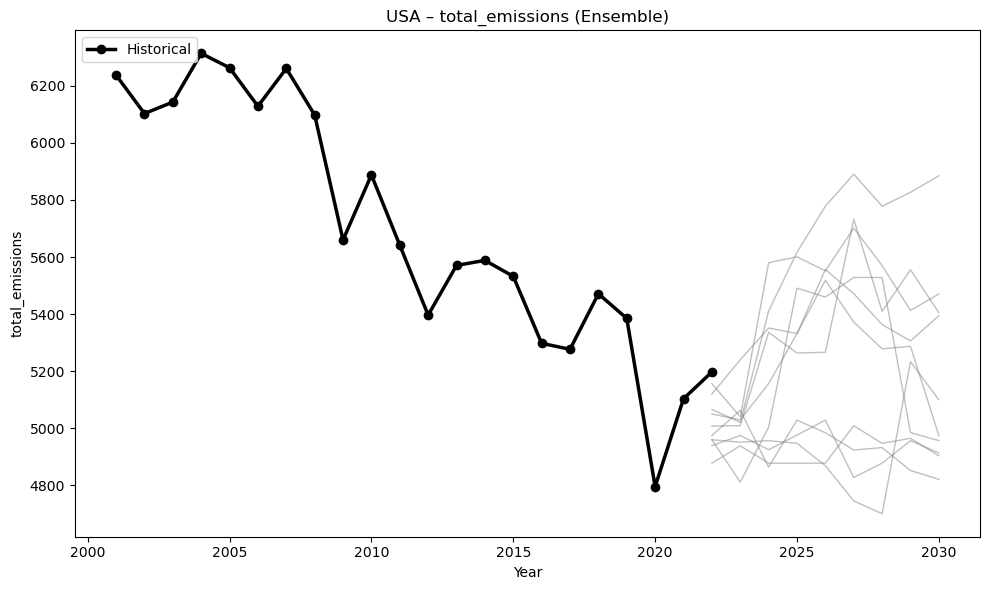

In [19]:
ep.plot_ensemble_time_series(
    df=xgb_with_isos_df, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df_lags)

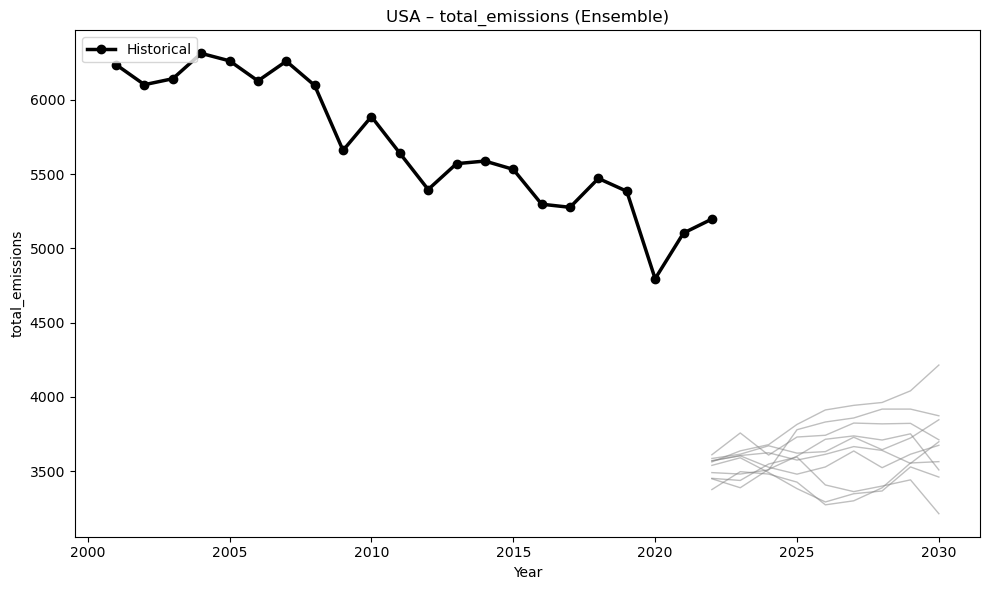

In [20]:
ep.plot_ensemble_time_series(
    df=enet_no_isos_df, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df_lags)

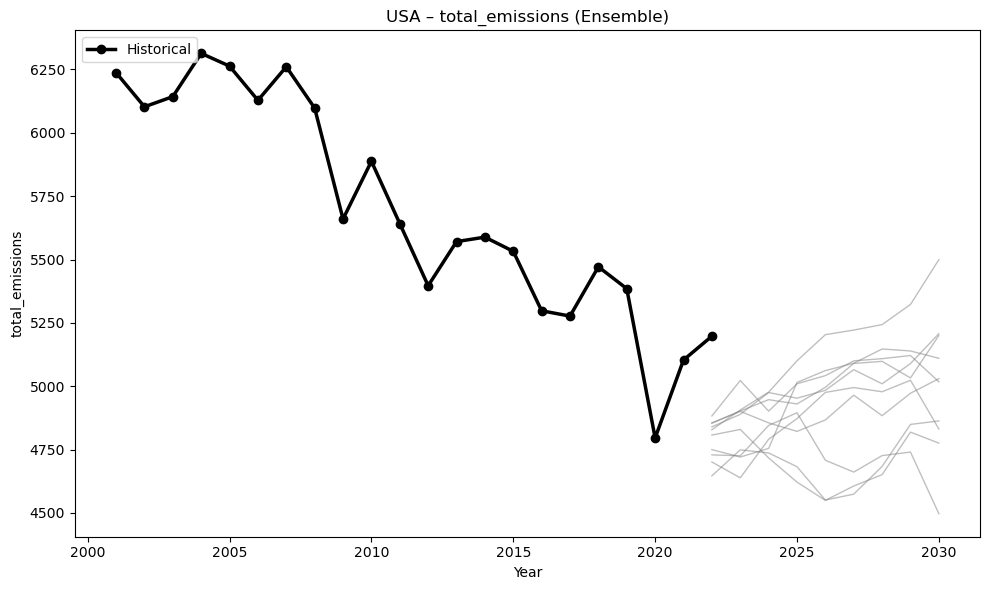

In [21]:
ep.plot_ensemble_time_series(
    df=enet_with_isos_df, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df_lags)

## Let's calibrate and plot again

In [22]:
xgb_no_isos_df_calibrated = ep.calibrate_total_emissions(
    simulated_df=xgb_no_isos_df,
    initial_emissions_df=initial_conditions_df,
    adjustment_method="additive"
)

enet_with_isos_df_calibrated = ep.calibrate_total_emissions(
    simulated_df=enet_with_isos_df,
    initial_emissions_df=initial_conditions_df,
    adjustment_method="additive"
)

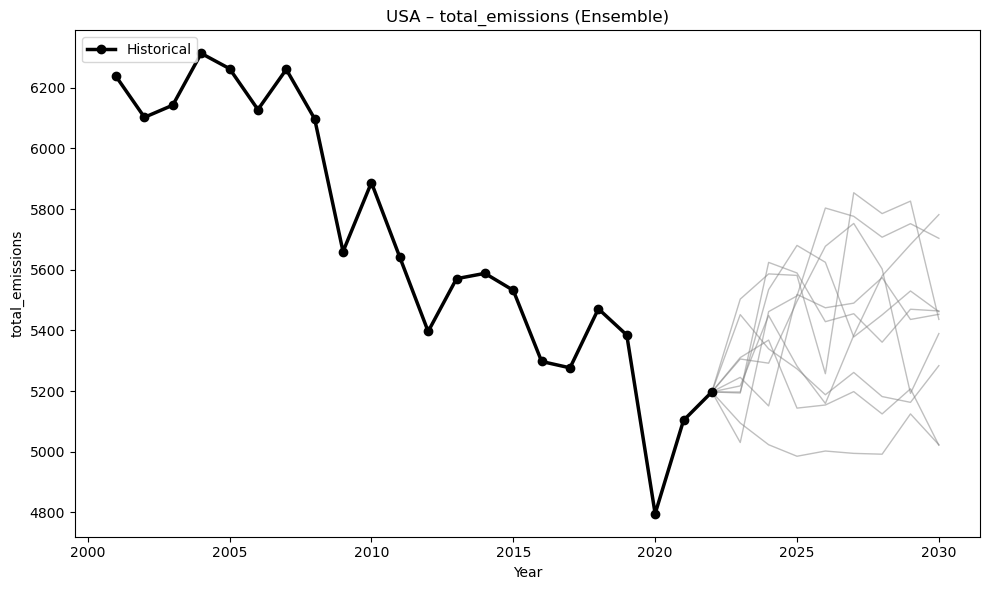

In [23]:
ep.plot_ensemble_time_series(
    df=xgb_no_isos_df_calibrated, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df_lags)

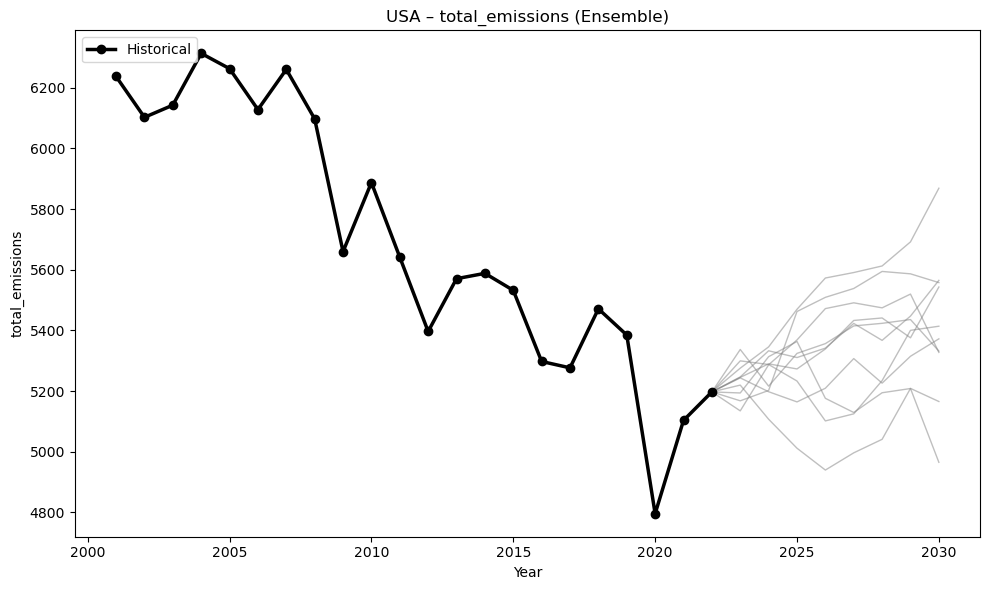

In [24]:
ep.plot_ensemble_time_series(
    df=enet_with_isos_df_calibrated, 
    iso_alpha_3="USA",
    column="total_emissions",
    hist_df=training_df_lags)